# Nearest Centroid

The data was preprocessed and a Nearest Centroid model was fit:
- Numerical columns scaled using StandardScaler
- Categorical columns one hot encoded
- GridSearchCV used to tune hyperparameters using cross-validation

The **key results** were:
- **36% Precision for Class 1:**
  - Of all the customers the model predicted would subscribe, 36% actually did.
- **69% Recall for Class 1:**
  - Of all the customers that subscribed, 69% were correctly identified by the model.
- **47% F1 Score for Class 1:**
  - The model achieves a moderate balance between correctly identifying subscribers and avoiding false positive predictions.
 
This model doesn't perform well. A recall for class 1 of 36% is too low for the model to be useful. A precision of 69% for class 1 is good but not excellent.

In [14]:
# change directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [15]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [16]:
# set random state for the notebook
random_state = 42
np.random.seed(random_state)

In [17]:
# import the data
data = pd.read_csv("data/processed/processed_data.csv")

# split data into x and y
x = data.select_dtypes(include='object')
y = data['target']

# split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best Parameters:
{'classifier__metric': 'euclidean', 'classifier__shrink_threshold': 7}


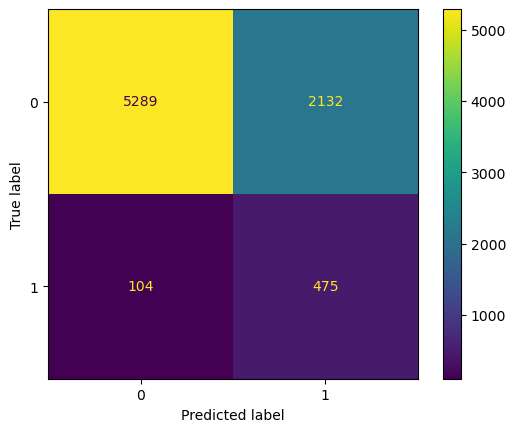

              precision    recall  f1-score   support

           0       0.98      0.71      0.83      7421
           1       0.18      0.82      0.30       579

    accuracy                           0.72      8000
   macro avg       0.58      0.77      0.56      8000
weighted avg       0.92      0.72      0.79      8000



In [18]:
# surpress zero stddev warning
import warnings
warnings.filterwarnings(
    "ignore",
    message="self.within_class_std_dev_ has at least 1 zero standard deviation.*"
)

# identify numerical and categorical features
cat_features = x.select_dtypes(include='object').columns

# preprocessing pipeline: scaling numerical features and one hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), cat_features)
    ])

# pipeline that performs preprocessing and then creates model
nc_pipe = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', NearestCentroid())
    ])

# hyperparameter options to try
param_grid = {
    'classifier__metric': ['euclidean', 'manhattan'],
    'classifier__shrink_threshold': [None, 0.1, 1, 2, 5, 7, 10]
}

# grid search to find best hyperparameters using cross validation
grid = GridSearchCV(
    nc_pipe, 
    param_grid, 
    cv=5,
    scoring='f1',
    n_jobs=1, 
    verbose=1
)

# fitting grid to data
grid.fit(x_train, y_train)

# display the best parameters
print('Best Parameters:')
print(grid.best_params_)

# make predictions on the test set using the best model
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

# show confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# show classification report
print(classification_report(y_test, y_pred))